In [61]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image
from typing import TypedDict

In [62]:
#define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    status: str

In [64]:
#define function to calculate BMI
def calc_bmi(state: BMIState) -> BMIState:
    state['bmi'] = state['weight_kg'] / (state['height_m'] ** 2)
    return state

In [65]:
#BMI status
def bmi_status(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['status'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['status'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['status'] = 'Overweight'
    else:
        state['status'] = 'Obese'
    return state

In [66]:
#define graph
graph = StateGraph(BMIState)

#add nodes
graph.add_node('calc_bmi', calc_bmi)
graph.add_node('bmi_status', bmi_status)

#add edges
graph.add_edge(START, 'calc_bmi')
graph.add_edge('calc_bmi', 'bmi_status')
graph.add_edge('bmi_status', END)

#compile graph
workflow = graph.compile()

In [67]:
#execute workflow
initial_state = {'weight_kg': 70, 'height_m': 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.857142857142858, 'status': 'Normal weight'}


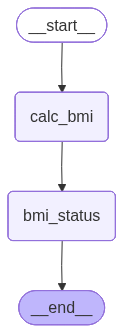

In [50]:
#visualize graph
Image(workflow.get_graph().draw_mermaid_png())